# 🎯 Risk Scoring & Pricing Model
**Objectif :** Pour chaque police, calculer :
1. **Score de risque [0–1000]** — probabilité pondérée de générer des sinistres coûteux
2. **Prime technique** — ce que la police *devrait* coûter selon son profil de risque réel
3. **Écart de tarification** — comparer la prime actuelle vs la prime technique

**Pipeline actuariel :**
```
Risque = Fréquence × Sévérité
Prime technique = E[Nb sinistres] × E[Coût sinistre] + Chargements
```

**Modèles :**
| Composante | Modèle | Distribution |
|---|---|---|
| Fréquence (nb sinistres) | XGBoost + GLM Poisson | Poisson |
| Sévérité (coût si sinistre) | XGBoost + GLM Gamma | Gamma / Tweedie |
| Score global | Ensemble pondéré | — |
| Prime technique | Fréquence × Sévérité + marge | — |

---

## 0. Setup

In [98]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.linear_model import PoissonRegressor, GammaRegressor, TweedieRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb
import shap

plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')
np.random.seed(42)

print('✅ Setup complet')

✅ Setup complet


## 1. Chargement & Construction du Dataset Police

In [99]:
def load(filename, date_cols=None):
    # Use absolute path to data directory for robustness
    import os
    base_dir = r'C:\Users\LENOVO\Desktop\PFE_\maghrebia\data\raw'
    path = os.path.join(base_dir, filename)
    # Remove unsupported 'low_memory' for engine='python'
    df = pd.read_csv(path, sep=None, engine='python')
    df.columns = df.columns.str.strip().str.lstrip('\ufeff')
    if date_cols:
        for c in date_cols:
            if c in df.columns:
                df[c] = pd.to_datetime(df[c], errors='coerce')
    return df

pol = load('DIM_POLICE.csv',          ['DATE_EFFET','DATE_ECHEANCE'])
cli = load('DIM_CLIENT.csv',          ['DATE_NAISSANCE'])
veh = load('DIM_VEHICULE.csv',        ['DATE_MEC'])
em  = load('DWH_FACT_EMISSION.csv',   ['DATE_EMISSION','DATE_EFFET','DATE_ECHEANCE'])
sin = load('DWH_FACT_SINISTRE.csv',   ['DATE_SURVENANCE'])
imp = load('DWH_FACT_IMPAYE.csv',     ['DATE_EMISSION'])
ann = load('DWH_FACT_ANNULATION.csv', ['DATE_ANNULATION'])

# ── Nettoyage TYPE_PERSONNE ───────────────────────────────────────────────
cli['TYPE_PERSONNE'] = cli['TYPE_PERSONNE'].str.strip().str.upper()

# ── KPIs par police depuis FACT_EMISSION ─────────────────────────────────
em['PRIME'] = em['MT_PTT'].fillna(em['MT_PNET'].fillna(0))
pol_em = em.groupby('ID_POLICE').agg(
    TOTAL_PRIMES    = ('PRIME',          'sum'),
    NB_QUITTANCES   = ('NUM_QUITTANCE',   'count'),
    PRIME_MOY       = ('PRIME',          'mean'),
    MT_COMMISSION   = ('MT_COMMISSION',  'sum'),
    MT_FGA          = ('MT_FGA',         'sum'),
    BONUS_MALUS_MOY = ('BONUS_MALUS',    'mean'),
    DATE_PREM_QUIT  = ('DATE_EMISSION',  'min'),
    DATE_DERN_QUIT  = ('DATE_EMISSION',  'max'),
).reset_index()

# ── KPIs sinistres par police ─────────────────────────────────────────────
pol_sin = sin.groupby('ID_POLICE').agg(
    NB_SINISTRES    = ('NUM_SINISTRE',   'count'),
    COUT_SINISTRES  = ('MT_PAYE',        'sum'),
    EVAL_SINISTRES  = ('MT_EVALUATION',  'sum'),
    COUT_MOY_SIN    = ('MT_PAYE',        'mean'),
    NB_SIN_MATERIEL = ('NATURE_SINISTRE', lambda x: (x=='Matériel').sum()),
    NB_SIN_VOL      = ('NATURE_SINISTRE', lambda x: (x=='Vol').sum()),
    NB_SIN_CORP     = ('NATURE_SINISTRE', lambda x: (x=='Corporel').sum()),
).reset_index()

# ── Impayés par police ────────────────────────────────────────────────────
pol_imp = imp.groupby('ID_POLICE').agg(
    NB_IMPAYES     = ('NUM_QUITTANCE', 'count'),
    MT_IMPAYE_TOT  = ('MT_PTT',        'sum'),
).reset_index()

# ── Annulations par police ────────────────────────────────────────────────
pol_ann = ann.groupby('ID_POLICE').agg(
    NB_ANNULATIONS = ('NUM_QUITTANCE', 'count'),
).reset_index()

# ── Assemblage du master police ───────────────────────────────────────────
master = (
    pol
    .merge(pol_em,  on='ID_POLICE', how='left')
    .merge(pol_sin, on='ID_POLICE', how='left')
    .merge(pol_imp, on='ID_POLICE', how='left')
    .merge(pol_ann, on='ID_POLICE', how='left')
)

# Remplissage des nulls numériques
fill_zero = ['NB_SINISTRES','COUT_SINISTRES','EVAL_SINISTRES','COUT_MOY_SIN',
             'NB_SIN_MATERIEL','NB_SIN_VOL','NB_SIN_CORP',
             'NB_IMPAYES','MT_IMPAYE_TOT','NB_ANNULATIONS',
             'MT_COMMISSION','MT_FGA']
master[fill_zero] = master[fill_zero].fillna(0)

print(f'Master police : {len(master):,} polices')
print(f'Avec sinistres : {(master["NB_SINISTRES"]>0).sum():,} ({(master["NB_SINISTRES"]>0).mean()*100:.1f}%)')
print(f'Avec impayés   : {(master["NB_IMPAYES"]>0).sum():,} ({(master["NB_IMPAYES"]>0).mean()*100:.1f}%)')

Master police : 30,000 polices
Avec sinistres : 6,834 (22.8%)
Avec impayés   : 853 (2.8%)


## 2. Feature Engineering — Profil de Risque Police

In [100]:
df = master.copy()

# ══════════════════════════════════════════════════════
# BLOC A — Features police / contrat
# ══════════════════════════════════════════════════════
df['EXPOSITION_JOURS'] = (
    (df['DATE_ECHEANCE'] - df['DATE_EFFET']).dt.days
).clip(1, 730)  # 1 jour à 2 ans
df['EXPOSITION_ANS'] = df['EXPOSITION_JOURS'] / 365.25

# Ancienneté client dans le portefeuille
df['ANCIENNETE_JOURS'] = (
    (df['DATE_ECHEANCE'] - df['DATE_EFFET']).dt.days * df['NB_QUITTANCES'].fillna(1)
).clip(0)

# Mois et trimestre d'effet
df['MOIS_EFFET']      = df['DATE_EFFET'].dt.month
df['TRIMESTRE_EFFET'] = df['DATE_EFFET'].dt.quarter
df['ANNEE_EFFET']     = df['DATE_EFFET'].dt.year

# Périodicité en score ordinal
per_risk = {'A': 1, 'S': 2, 'T': 3, 'C': 4}
df['PERIODICITE_SCORE'] = df['PERIODICITE'].map(per_risk).fillna(2)

# Type police
df['FLAG_FLOTTE'] = (df['TYPE_POLICE'] == 'flotte').astype(int)

# ══════════════════════════════════════════════════════
# BLOC B — Véhicule
# ══════════════════════════════════════════════════════
veh_clean = veh[[
    'ID_POLICE','MARQUE','PUISSANCE','GENRE_VEHICULE','TYPE_VEHICULE',
    'NB_PLACE','DATE_MEC','VALEUR_A_NEUF','VALEUR_ACTUELLE',
    'CHARGE_UTILE','POIDS_TOTAL','CODE_USAGE'
]].drop_duplicates('ID_POLICE')

df = df.merge(veh_clean, on='ID_POLICE', how='left')

# Âge véhicule à l'effet du contrat
df['AGE_VEHICULE'] = (
    (df['DATE_EFFET'] - df['DATE_MEC']).dt.days / 365.25
).clip(0, 50)

# Taux de dépréciation
df['VALEUR_A_NEUF']    = df['VALEUR_A_NEUF'].clip(0, df['VALEUR_A_NEUF'].quantile(0.99))
df['VALEUR_ACTUELLE']  = df['VALEUR_ACTUELLE'].clip(0, df['VALEUR_ACTUELLE'].quantile(0.99))
df['TAUX_DEPRECIATION'] = np.where(
    df['VALEUR_A_NEUF'] > 0,
    1 - df['VALEUR_ACTUELLE'] / df['VALEUR_A_NEUF'], 0
).clip(0, 1)

df['LOG_VALEUR_VEH']   = np.log1p(df['VALEUR_ACTUELLE'].fillna(0))
df['LOG_VALEUR_NEUF']  = np.log1p(df['VALEUR_A_NEUF'].fillna(0))

# Puissance → catégorie risque
df['CAT_PUISSANCE'] = pd.cut(
    df['PUISSANCE'].fillna(df['PUISSANCE'].median()),
    bins=[0, 6, 9, 12, 16, 100],
    labels=[1, 2, 3, 4, 5]
).astype(float)

# ══════════════════════════════════════════════════════
# BLOC C — Client
# ══════════════════════════════════════════════════════
cli_clean = cli[[
    'ID_CLIENT','TYPE_PERSONNE','SEXE','DATE_NAISSANCE','NATP'
]].drop_duplicates('ID_CLIENT')
cli_clean['TYPE_PERSONNE'] = cli_clean['TYPE_PERSONNE'].str.strip().str.upper()

df = df.merge(cli_clean, on='ID_CLIENT', how='left')

df['AGE_CLIENT'] = (
    (df['DATE_EFFET'] - df['DATE_NAISSANCE']).dt.days / 365.25
).clip(18, 90)

# Flag personne morale (sociétés = comportement différent)
df['FLAG_MORALE'] = (df['TYPE_PERSONNE'] == 'M').astype(int)

# ══════════════════════════════════════════════════════
# BLOC D — KPIs sinistralité (targets + features historiques)
# ══════════════════════════════════════════════════════

# Fréquence annualisée
df['FREQ_SINISTRE'] = df['NB_SINISTRES'] / df['EXPOSITION_ANS'].clip(0.1)

# Sévérité moyenne (coût par sinistre)
df['SEVERITE_MOY'] = np.where(
    df['NB_SINISTRES'] > 0,
    df['EVAL_SINISTRES'] / df['NB_SINISTRES'], 0
)

# Prime pure historique (coût sinistres / primes)
df['SP_RATIO'] = np.where(
    df['TOTAL_PRIMES'] > 0,
    df['COUT_SINISTRES'] / df['TOTAL_PRIMES'], 0
).clip(0, 20)

# Prime technique vs prime réelle
df['PRIME_PAR_AN'] = df['TOTAL_PRIMES'] / df['EXPOSITION_ANS'].clip(0.1)

# ══════════════════════════════════════════════════════
# BLOC E — Comportement de paiement (feature, pas target)
# ══════════════════════════════════════════════════════
df['TAUX_IMPAYE'] = np.where(
    df['NB_QUITTANCES'] > 0,
    df['NB_IMPAYES'] / df['NB_QUITTANCES'], 0
)

# Encodage catégoriel
cat_cols = ['BRANCHE','MARQUE','GENRE_VEHICULE','TYPE_VEHICULE','NATP']
encoders = {}
for col in cat_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[f'{col}_ENC'] = le.fit_transform(df[col].astype(str).fillna('INC'))
        encoders[col] = le

print(f'Dataset enrichi : {df.shape}')
print(f'FREQ_SINISTRE moy : {df["FREQ_SINISTRE"].mean():.3f} sin/an')
print(f'SEVERITE_MOY moy  : {df[df["SEVERITE_MOY"]>0]["SEVERITE_MOY"].mean():,.0f} TND')
print(f'SP_RATIO moy      : {df["SP_RATIO"].mean():.3f}')

Dataset enrichi : (30000, 74)
FREQ_SINISTRE moy : 0.266 sin/an
SEVERITE_MOY moy  : 2,936 TND
SP_RATIO moy      : 0.467


## 3. Analyse Exploratoire du Risque

In [101]:
fig = make_subplots(rows=2, cols=3, subplot_titles=[
    'Fréquence sinistre par Branche',
    'Sévérité moyenne par Branche',
    'Fréquence par Bonus/Malus',
    'Fréquence par Puissance Véhicule',
    'S/P Ratio par Branche',
    'Distribution Fréquence annualisée'
])

# Fréquence par branche
br_freq = df.groupby('BRANCHE')['FREQ_SINISTRE'].mean().sort_values()
fig.add_trace(go.Bar(x=br_freq.values, y=br_freq.index, orientation='h',
                     marker_color='steelblue'), row=1, col=1)

# Sévérité par branche
br_sev = df[df['SEVERITE_MOY']>0].groupby('BRANCHE')['SEVERITE_MOY'].median().sort_values()
fig.add_trace(go.Bar(x=br_sev.values, y=br_sev.index, orientation='h',
                     marker_color='darkorange'), row=1, col=2)

# Par bonus/malus
bm_freq = df.groupby('BONUS_MALUS')['FREQ_SINISTRE'].mean()
fig.add_trace(go.Scatter(x=bm_freq.index, y=bm_freq.values,
                          mode='lines+markers', marker_color='crimson'), row=1, col=3)

# Par puissance
df['PUISSANCE_CLIP'] = df['PUISSANCE'].clip(4, 20)
pu_freq = df.groupby('PUISSANCE_CLIP')['FREQ_SINISTRE'].mean()
fig.add_trace(go.Bar(x=pu_freq.index.astype(str), y=pu_freq.values,
                     marker_color='teal'), row=2, col=1)

# S/P par branche
br_sp = df.groupby('BRANCHE')['SP_RATIO'].median().sort_values()
fig.add_trace(go.Bar(x=br_sp.values, y=br_sp.index, orientation='h',
                     marker_color='purple'), row=2, col=2)

# Distribution fréquence
fig.add_trace(go.Histogram(x=df['FREQ_SINISTRE'].clip(0, 3), nbinsx=50,
                            marker_color='gold', opacity=0.8), row=2, col=3)

fig.update_layout(height=620, title_text='📊 Analyse du Risque — Niveau Police',
                  showlegend=False)
fig.show()

In [102]:
# Table de risque par branche × type véhicule
risk_table = df.groupby(['BRANCHE','GENRE_VEHICULE']).agg(
    NB_POLICES   = ('ID_POLICE',     'count'),
    FREQ_SIN_MOY = ('FREQ_SINISTRE', 'mean'),
    SEV_MOY      = ('SEVERITE_MOY',  'mean'),
    SP_RATIO_MOY = ('SP_RATIO',      'mean'),
    PRIME_MOY    = ('PRIME_PAR_AN',  'mean'),
).round(3)

risk_table['PRIME_TECHNIQUE'] = (
    risk_table['FREQ_SIN_MOY'] * risk_table['SEV_MOY']
).round(0)

display(risk_table.style
    .background_gradient(subset=['FREQ_SIN_MOY'], cmap='YlOrRd')
    .background_gradient(subset=['SP_RATIO_MOY'], cmap='RdYlGn_r')
    .format({
        'FREQ_SIN_MOY': '{:.3f}',
        'SEV_MOY': '{:,.0f}',
        'SP_RATIO_MOY': '{:.2f}',
        'PRIME_MOY': '{:,.0f}',
        'PRIME_TECHNIQUE': '{:,.0f}'
    })
    .set_caption('Table de Risque Actuariel — Branche × Genre Véhicule')
)

## 4. Préparation des Datasets
On entraîne **deux modèles séparés** (approche actuarielle standard) :
- **Modèle de Fréquence** : prédit le nombre de sinistres/an → target = `NB_SINISTRES`
- **Modèle de Sévérité** : prédit le coût si sinistre → target = `SEVERITE_MOY` (sur polices sinistres uniquement)

In [103]:
FEATURE_COLS = [
    # Contrat
    'BONUS_MALUS', 'PERIODICITE_SCORE', 'FLAG_FLOTTE',
    'MOIS_EFFET', 'TRIMESTRE_EFFET', 'ANNEE_EFFET',
    'NB_QUITTANCES', 'EXPOSITION_ANS',
    'BRANCHE_ENC', 'ID_BRANCHE',
    # Véhicule
    'PUISSANCE', 'CAT_PUISSANCE', 'AGE_VEHICULE',
    'LOG_VALEUR_VEH', 'LOG_VALEUR_NEUF', 'TAUX_DEPRECIATION',
    'NB_PLACE', 'CHARGE_UTILE', 'POIDS_TOTAL', 'CODE_USAGE',
    'GENRE_VEHICULE_ENC', 'MARQUE_ENC',
    # Client
    'AGE_CLIENT', 'FLAG_MORALE', 'NATP_ENC',
    # Comportement
    'TAUX_IMPAYE', 'NB_IMPAYES', 'NB_ANNULATIONS',
    # Prime
    'PRIME_PAR_AN', 'PRIME_MOY',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

# ── Dataset Fréquence ─────────────────────────────────────────────────────
# Target : nb sinistres (entier ≥ 0)
df_freq = df[df['ANNEE_EFFET'].between(2019, 2024)].copy()
df_freq['TARGET_FREQ'] = df_freq['NB_SINISTRES'].fillna(0).astype(int).clip(0, 10)

X_freq = df_freq[FEATURE_COLS].fillna(df_freq[FEATURE_COLS].median())
y_freq = df_freq['TARGET_FREQ']

# ── Dataset Sévérité ──────────────────────────────────────────────────────
# Target : coût moyen par sinistre (sur polices avec ≥ 1 sinistre)
df_sev = df_freq[df_freq['NB_SINISTRES'] >= 1].copy()
df_sev['TARGET_SEV'] = df_sev['SEVERITE_MOY'].clip(0, df_sev['SEVERITE_MOY'].quantile(0.99))
df_sev['LOG_TARGET_SEV'] = np.log1p(df_sev['TARGET_SEV'])

X_sev = df_sev[FEATURE_COLS].fillna(df_sev[FEATURE_COLS].median())
y_sev = df_sev['LOG_TARGET_SEV']

# ── Splits temporels ─────────────────────────────────────────────────────
train_mask_freq = df_freq['ANNEE_EFFET'] <= 2022
test_mask_freq  = df_freq['ANNEE_EFFET'] >= 2023

X_freq_tr, X_freq_te = X_freq[train_mask_freq], X_freq[test_mask_freq]
y_freq_tr, y_freq_te = y_freq[train_mask_freq], y_freq[test_mask_freq]

train_mask_sev = df_sev['ANNEE_EFFET'] <= 2022
test_mask_sev  = df_sev['ANNEE_EFFET'] >= 2023

X_sev_tr, X_sev_te = X_sev[train_mask_sev], X_sev[test_mask_sev]
y_sev_tr, y_sev_te = y_sev[train_mask_sev], y_sev[test_mask_sev]

print(f'Fréquence — Train: {len(X_freq_tr):,} | Test: {len(X_freq_te):,}')
print(f'  Moy sinistres/an train : {y_freq_tr.mean():.3f}')
print(f'Sévérité  — Train: {len(X_sev_tr):,} | Test: {len(X_sev_te):,}')
print(f'  Moy coût sinistre train: {np.expm1(y_sev_tr).mean():,.0f} TND')

Fréquence — Train: 19,314 | Test: 9,640
  Moy sinistres/an train : 0.265
Sévérité  — Train: 4,368 | Test: 2,209
  Moy coût sinistre train: 2,528 TND


## 5. Modèle de Fréquence — GLM Poisson + XGBoost

In [104]:
freq_results = []

def eval_freq(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # Gini (corrélation rang)
    gini = np.corrcoef(y_true, y_pred)[0, 1]
    # Biais relatif
    biais = (y_pred.mean() - y_true.mean()) / (y_true.mean() + 1e-9) * 100
    print(f'  {name:25s} MAE={mae:.4f} | RMSE={rmse:.4f} | Gini={gini:.4f} | Biais={biais:+.1f}%')
    freq_results.append({'Modèle': name, 'MAE': mae, 'RMSE': rmse, 'Gini': gini, 'Biais%': biais})
    return y_pred

scaler_freq = StandardScaler()
X_freq_tr_s = scaler_freq.fit_transform(X_freq_tr)
X_freq_te_s = scaler_freq.transform(X_freq_te)

# GLM Poisson (modèle actuariel classique)
glm_poisson = PoissonRegressor(alpha=0.1, max_iter=500)
glm_poisson.fit(X_freq_tr_s, y_freq_tr)
pred_poisson = glm_poisson.predict(X_freq_te_s)
eval_freq(y_freq_te, pred_poisson, 'GLM Poisson')

# XGBoost Poisson
xgb_freq = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.03,
    max_depth=4, subsample=0.8, colsample_bytree=0.8,
    objective='count:poisson',
    min_child_weight=10,
    early_stopping_rounds=30, eval_metric='poisson-nloglik',
    random_state=42, n_jobs=-1
)
xgb_freq.fit(X_freq_tr, y_freq_tr,
             eval_set=[(X_freq_te, y_freq_te)], verbose=False)
pred_xgb_freq = xgb_freq.predict(X_freq_te)
eval_freq(y_freq_te, pred_xgb_freq, 'XGBoost Poisson')

# LightGBM Poisson
lgb_freq = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.03,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    objective='poisson', min_child_samples=20,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_freq.fit(X_freq_tr, y_freq_tr,
             eval_set=[(X_freq_te, y_freq_te)],
             callbacks=[lgb.early_stopping(30,verbose=False), lgb.log_evaluation(-1)])
pred_lgb_freq = lgb_freq.predict(X_freq_te)
eval_freq(y_freq_te, pred_lgb_freq, 'LightGBM Poisson')

# Ensemble fréquence
pred_freq_ensemble = 0.4 * pred_xgb_freq + 0.6 * pred_lgb_freq
eval_freq(y_freq_te, pred_freq_ensemble, 'Ensemble (XGB+LGB)')

  GLM Poisson               MAE=0.4053 | RMSE=0.5277 | Gini=0.2114 | Biais=+1.1%
  XGBoost Poisson           MAE=0.3932 | RMSE=0.5239 | Gini=0.2239 | Biais=-1.4%
  LightGBM Poisson          MAE=0.3939 | RMSE=0.5238 | Gini=0.2268 | Biais=-1.8%
  Ensemble (XGB+LGB)        MAE=0.3936 | RMSE=0.5236 | Gini=0.2270 | Biais=-1.6%


array([0.260284  , 0.25500458, 0.2584212 , ..., 0.72382452, 0.6117648 ,
       0.67777847])

## 6. Modèle de Sévérité — GLM Gamma + XGBoost

In [105]:
sev_results = []

def eval_sev(y_true_log, y_pred_log, name):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = mean_absolute_percentage_error(y_true, y_pred) * 100
    gini  = np.corrcoef(y_true, y_pred)[0, 1]
    biais = (y_pred.mean() - y_true.mean()) / y_true.mean() * 100
    print(f'  {name:25s} MAE={mae:>8,.0f} TND | MAPE={mape:5.1f}% | Gini={gini:.4f} | Biais={biais:+.1f}%')
    sev_results.append({'Modèle': name, 'MAE': mae, 'MAPE': mape, 'Gini': gini, 'Biais%': biais})
    return y_pred

scaler_sev = StandardScaler()
X_sev_tr_s = scaler_sev.fit_transform(X_sev_tr)
X_sev_te_s = scaler_sev.transform(X_sev_te)

# GLM Gamma (distribution des coûts sinistres)
glm_gamma = GammaRegressor(alpha=1.0, max_iter=500)
glm_gamma.fit(X_sev_tr_s, np.expm1(y_sev_tr).clip(1))
pred_gamma_raw = np.log1p(glm_gamma.predict(X_sev_te_s))
eval_sev(y_sev_te, pred_gamma_raw, 'GLM Gamma')

# XGBoost
xgb_sev = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.03,
    max_depth=5, subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, reg_alpha=0.1,
    objective='reg:squarederror',
    early_stopping_rounds=30, eval_metric='rmse',
    random_state=42, n_jobs=-1
)
xgb_sev.fit(X_sev_tr, y_sev_tr,
            eval_set=[(X_sev_te, y_sev_te)], verbose=False)
pred_xgb_sev = xgb_sev.predict(X_sev_te)
eval_sev(y_sev_te, pred_xgb_sev, 'XGBoost')

# LightGBM
lgb_sev = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.03,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    min_child_samples=10, objective='regression',
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_sev.fit(X_sev_tr, y_sev_tr,
            eval_set=[(X_sev_te, y_sev_te)],
            callbacks=[lgb.early_stopping(30,verbose=False), lgb.log_evaluation(-1)])
pred_lgb_sev = lgb_sev.predict(X_sev_te)
eval_sev(y_sev_te, pred_lgb_sev, 'LightGBM')

# Ensemble sévérité
pred_sev_ensemble = 0.5 * pred_xgb_sev + 0.5 * pred_lgb_sev
eval_sev(y_sev_te, pred_sev_ensemble, 'Ensemble (XGB+LGB)')

  GLM Gamma                 MAE=   2,362 TND | MAPE=622.9% | Gini=0.3550 | Biais=-7.8%
  XGBoost                   MAE=   1,889 TND | MAPE=131.6% | Gini=0.4629 | Biais=-48.2%
  LightGBM                  MAE=   1,892 TND | MAPE=132.5% | Gini=0.4565 | Biais=-48.0%
  Ensemble (XGB+LGB)        MAE=   1,889 TND | MAPE=131.8% | Gini=0.4616 | Biais=-48.1%


array([ 985.77566044, 1064.49075764,  874.49840666, ...,  175.62609059,
        181.20913246,  134.98756394])

## 7. Prime Technique = Fréquence × Sévérité

In [106]:
# Prédire fréquence et sévérité sur TOUT le portefeuille
X_all = df_freq[FEATURE_COLS].fillna(df_freq[FEATURE_COLS].median())

df_freq['PRED_FREQ']    = lgb_freq.predict(X_all).clip(0)
df_freq['PRED_SEV']     = np.expm1(lgb_sev.predict(X_all)).clip(0)

# Prime pure = E[Nb sin] × E[Coût sin]
df_freq['PRIME_PURE']   = df_freq['PRED_FREQ'] * df_freq['PRED_SEV']

# Prime technique = Prime pure + chargements
CHARGEMENT_FRAIS    = 0.20   # 20% frais de gestion
CHARGEMENT_MARGE    = 0.05   # 5%  marge bénéficiaire
CHARGEMENT_FGA      = 0.03   # 3%  fonds de garantie

CHARGEMENT_TOTAL    = 1 + CHARGEMENT_FRAIS + CHARGEMENT_MARGE + CHARGEMENT_FGA

df_freq['PRIME_TECHNIQUE'] = (df_freq['PRIME_PURE'] * CHARGEMENT_TOTAL).round(0)

# Écart tarifaire : prime actuelle vs prime technique
df_freq['ECART_PRIME']     = df_freq['PRIME_PAR_AN'] - df_freq['PRIME_TECHNIQUE']
df_freq['ECART_PRIME_PCT'] = np.where(
    df_freq['PRIME_TECHNIQUE'] > 0,
    df_freq['ECART_PRIME'] / df_freq['PRIME_TECHNIQUE'] * 100, 0
).clip(-200, 200)

# Polices sous-tarifées vs sur-tarifées
sous_tarif = (df_freq['ECART_PRIME'] < 0) & (df_freq['PRIME_TECHNIQUE'] > 0)
sur_tarif  = (df_freq['ECART_PRIME'] > 0) & (df_freq['PRIME_TECHNIQUE'] > 0)

print(f'Polices sous-tarifées (prime < technique) : {sous_tarif.sum():,} ({sous_tarif.mean()*100:.1f}%)')
print(f'Polices sur-tarifées  (prime > technique) : {sur_tarif.sum():,}  ({sur_tarif.mean()*100:.1f}%)')
print(f'\nManque à gagner total (sous-tarif)   : {df_freq.loc[sous_tarif,"ECART_PRIME"].sum():>15,.0f} TND')
print(f'Excédent total         (sur-tarif)   : {df_freq.loc[sur_tarif,"ECART_PRIME"].sum():>15,.0f} TND')

Polices sous-tarifées (prime < technique) : 5,927 (20.5%)
Polices sur-tarifées  (prime > technique) : 16,360  (56.5%)

Manque à gagner total (sous-tarif)   :      -3,012,417 TND
Excédent total         (sur-tarif)   :     289,870,843 TND


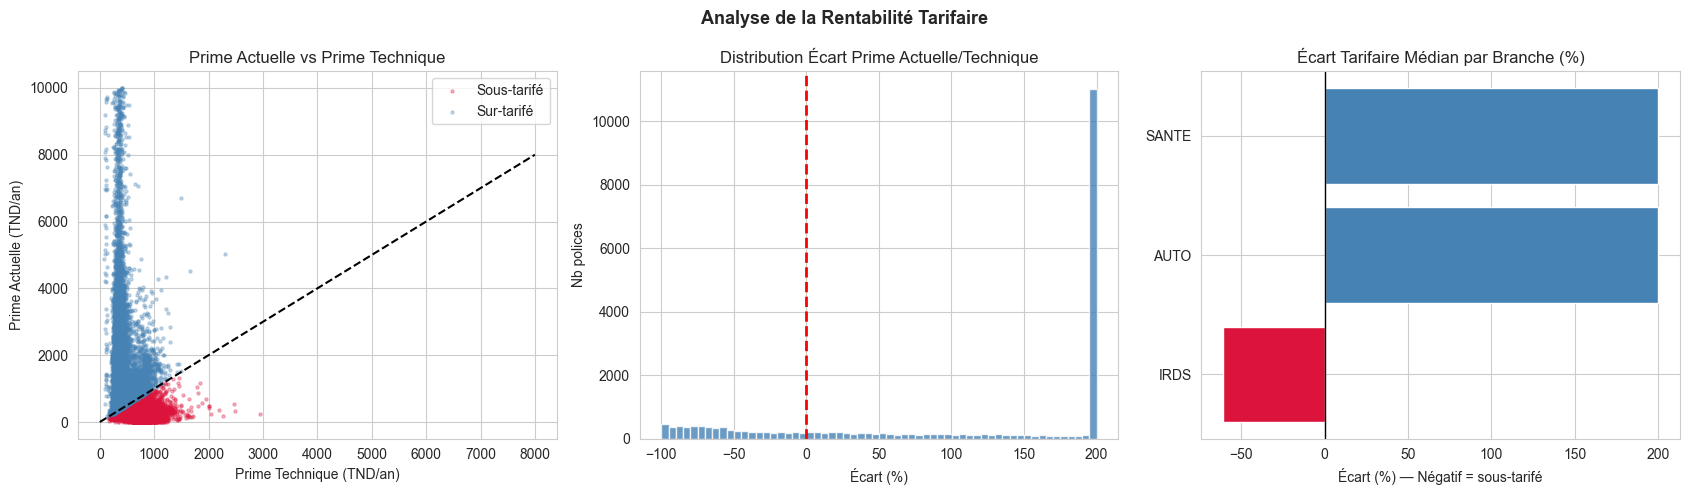

In [107]:
# Visualisation prime actuelle vs prime technique
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Scatter
mask_plot = (
    (df_freq['PRIME_PAR_AN'] > 0) &
    (df_freq['PRIME_TECHNIQUE'] > 0) &
    (df_freq['PRIME_PAR_AN'] < 10000) &
    (df_freq['PRIME_TECHNIQUE'] < 10000)
)
ax = axes[0]
ax.scatter(
    df_freq.loc[mask_plot & sous_tarif, 'PRIME_TECHNIQUE'],
    df_freq.loc[mask_plot & sous_tarif, 'PRIME_PAR_AN'],
    s=5, alpha=0.3, color='crimson', label='Sous-tarifé'
)
ax.scatter(
    df_freq.loc[mask_plot & sur_tarif, 'PRIME_TECHNIQUE'],
    df_freq.loc[mask_plot & sur_tarif, 'PRIME_PAR_AN'],
    s=5, alpha=0.3, color='steelblue', label='Sur-tarifé'
)
lim = 8000
ax.plot([0,lim],[0,lim],'k--',linewidth=1.5)
ax.set_xlabel('Prime Technique (TND/an)'); ax.set_ylabel('Prime Actuelle (TND/an)')
ax.set_title('Prime Actuelle vs Prime Technique'); ax.legend()

# Distribution écart %
ecart_plot = df_freq.loc[
    (df_freq['PRIME_TECHNIQUE']>0) & (df_freq['PRIME_PAR_AN']>0),
    'ECART_PRIME_PCT'
]
axes[1].hist(ecart_plot, bins=60, color='steelblue', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Écart (%)'); axes[1].set_title('Distribution Écart Prime Actuelle/Technique')
axes[1].set_ylabel('Nb polices')

# Écart par branche
br_ecart = df_freq.groupby('BRANCHE')['ECART_PRIME_PCT'].median().sort_values()
colors = ['crimson' if v < 0 else 'steelblue' for v in br_ecart.values]
axes[2].barh(br_ecart.index, br_ecart.values, color=colors)
axes[2].axvline(0, color='black', linewidth=1)
axes[2].set_title('Écart Tarifaire Médian par Branche (%)')
axes[2].set_xlabel('Écart (%) — Négatif = sous-tarifé')

plt.suptitle('Analyse de la Rentabilité Tarifaire', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

## 8. Score de Risque Global [0–1000]

In [108]:
# Le score de risque combine :
# 1. Fréquence prédite (normalisée)
# 2. Sévérité prédite (normalisée)
# 3. Taux impayé (comportement paiement)

# Ancres du portefeuille — sauvegardées pour normaliser les cas individuels
NORM_ANCHORS = {}

def normalize_0_1000(series, key=None):
    """Normalise sur [0,1000]. Si key fourni, sauvegarde/réutilise les ancres p1/p99."""
    if key and key in NORM_ANCHORS:
        p1, p99 = NORM_ANCHORS[key]
    else:
        p1  = series.quantile(0.01)
        p99 = series.quantile(0.99)
        if key:
            NORM_ANCHORS[key] = (p1, p99)
    denom = p99 - p1
    if denom == 0:
        return pd.Series([500.0] * len(series), index=series.index)
    return ((series.clip(p1, p99) - p1) / denom * 1000).clip(0, 1000)

def normalize_scalar(value, key):
    """Normalise un scalaire individuel en utilisant les ancres portefeuille."""
    if key not in NORM_ANCHORS:
        return 500.0
    p1, p99 = NORM_ANCHORS[key]
    denom = p99 - p1
    if denom == 0:
        return 500.0
    return float(np.clip((value - p1) / denom * 1000, 0, 1000))

df_freq['SCORE_FREQ']    = normalize_0_1000(df_freq['PRED_FREQ'],   key='FREQ')
df_freq['SCORE_SEV']     = normalize_0_1000(df_freq['PRED_SEV'],    key='SEV')
df_freq['SCORE_IMPAYE']  = normalize_0_1000(df_freq['TAUX_IMPAYE'], key='IMPAYE')

# Score global pondéré
# Fréquence compte pour 45%, Sévérité 40%, Impayé 15%
W_FREQ   = 0.45
W_SEV    = 0.40
W_IMPAYE = 0.15

df_freq['RISK_SCORE'] = (
    W_FREQ   * df_freq['SCORE_FREQ'] +
    W_SEV    * df_freq['SCORE_SEV'] +
    W_IMPAYE * df_freq['SCORE_IMPAYE']
).round(0).astype(int)

# Segmentation en 5 classes
q20 = df_freq['RISK_SCORE'].quantile(0.20)
q40 = df_freq['RISK_SCORE'].quantile(0.40)
q60 = df_freq['RISK_SCORE'].quantile(0.60)
q80 = df_freq['RISK_SCORE'].quantile(0.80)

def classify_risk(score):
    if score <= q20:   return ('A — Excellent',  '#27ae60')
    elif score <= q40: return ('B — Bon',         '#2ecc71')
    elif score <= q60: return ('C — Moyen',       '#f39c12')
    elif score <= q80: return ('D — Élevé',       '#e67e22')
    else:              return ('E — Critique',    '#c0392b')

df_freq['RISK_CLASS']  = df_freq['RISK_SCORE'].apply(lambda s: classify_risk(s)[0])
df_freq['RISK_COLOR']  = df_freq['RISK_SCORE'].apply(lambda s: classify_risk(s)[1])

# Stats par classe
class_stats = df_freq.groupby('RISK_CLASS').agg(
    NB_POLICES       = ('ID_POLICE',          'count'),
    RISK_SCORE_MOY   = ('RISK_SCORE',          'mean'),
    FREQ_REEL        = ('NB_SINISTRES',        lambda x: (x > 0).mean()),
    SP_RATIO         = ('SP_RATIO',            'mean'),
    PRIME_ACT        = ('PRIME_PAR_AN',        'mean'),
    PRIME_TECH       = ('PRIME_TECHNIQUE',     'mean'),
    ECART_PCT        = ('ECART_PRIME_PCT',     'mean'),
).round(2)

display(class_stats.style
    .background_gradient(subset=['FREQ_REEL','SP_RATIO'], cmap='YlOrRd')
    .background_gradient(subset=['ECART_PCT'], cmap='RdYlGn')
    .format({
        'FREQ_REEL':    '{:.1%}',
        'SP_RATIO':     '{:.2f}',
        'PRIME_ACT':    '{:,.0f}',
        'PRIME_TECH':   '{:,.0f}',
        'ECART_PCT':    '{:+.1f}%',
        'RISK_SCORE_MOY': '{:.0f}'
    })
    .set_caption('Performance par Classe de Risque')
)

,NB_POLICES,RISK_SCORE_MOY,FREQ_REEL,SP_RATIO,PRIME_ACT,PRIME_TECH,ECART_PCT
RISK_CLASS,,,,,,,
A — Excellent,6057,125,15.0%,0.10,"11,720",295,+160.2%
B — Bon,5552,149,19.0%,0.13,"7,013",345,+158.7%
C — Moyen,5798,171,25.0%,0.27,"4,760",395,+132.6%
D — Élevé,5787,244,24.0%,0.89,"3,128",595,+23.3%
E — Critique,5760,364,31.0%,0.92,"38,241",629,+47.6%


In [109]:
# Dashboard Risk Score
fig = make_subplots(rows=1, cols=3, subplot_titles=[
    'Distribution du Risk Score',
    'Fréquence Réelle par Classe',
    'Écart Tarifaire par Classe'
])

# Distribution
for cls, color in [('A — Excellent','#27ae60'),('B — Bon','#2ecc71'),
                   ('C — Moyen','#f39c12'),('D — Élevé','#e67e22'),
                   ('E — Critique','#c0392b')]:
    sub = df_freq[df_freq['RISK_CLASS'] == cls]
    fig.add_trace(go.Histogram(x=sub['RISK_SCORE'], nbinsx=40,
                               name=cls, marker_color=color, opacity=0.8), row=1, col=1)

# Fréquence par classe
freq_cls = class_stats['FREQ_REEL'] * 100
fig.add_trace(go.Bar(x=freq_cls.index, y=freq_cls.values,
                     marker_color=['#27ae60','#2ecc71','#f39c12','#e67e22','#c0392b']), row=1, col=2)

# Écart tarifaire
ecart_cls = class_stats['ECART_PCT']
fig.add_trace(go.Bar(x=ecart_cls.index, y=ecart_cls.values,
                     marker_color=['#27ae60' if v >= 0 else '#c0392b' for v in ecart_cls.values]), row=1, col=3)

fig.update_layout(height=420, title_text='🎯 Dashboard Risk Score — Vue Portefeuille',
                  showlegend=False)
fig.show()

## 9. Explainabilité SHAP — Drivers du Score de Risque

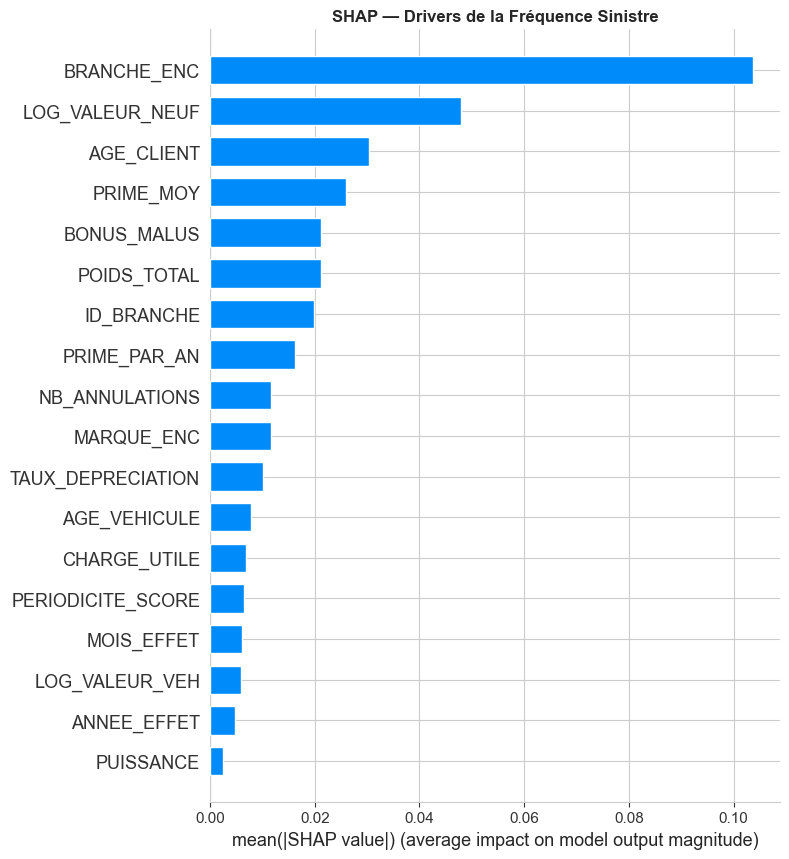

In [110]:
# SHAP sur le modèle de fréquence (principal driver du score)
explainer_freq = shap.TreeExplainer(lgb_freq)
shap_freq = explainer_freq.shap_values(X_freq_te)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_freq, X_freq_te, feature_names=FEATURE_COLS,
                  plot_type='bar', show=False, max_display=18)
plt.title('SHAP — Drivers de la Fréquence Sinistre', fontweight='bold')
plt.tight_layout(); plt.show()

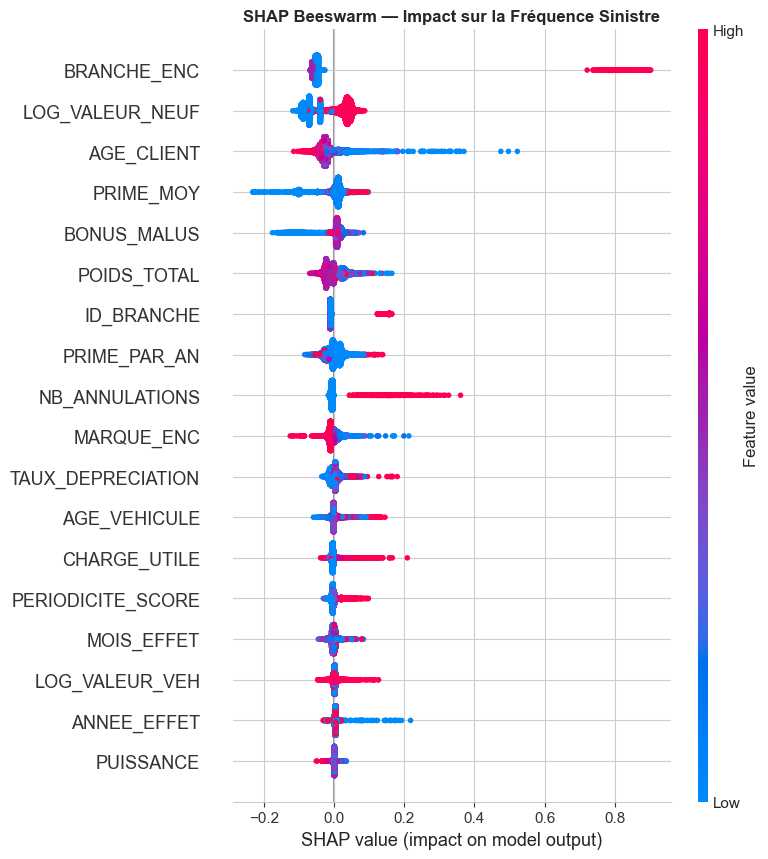

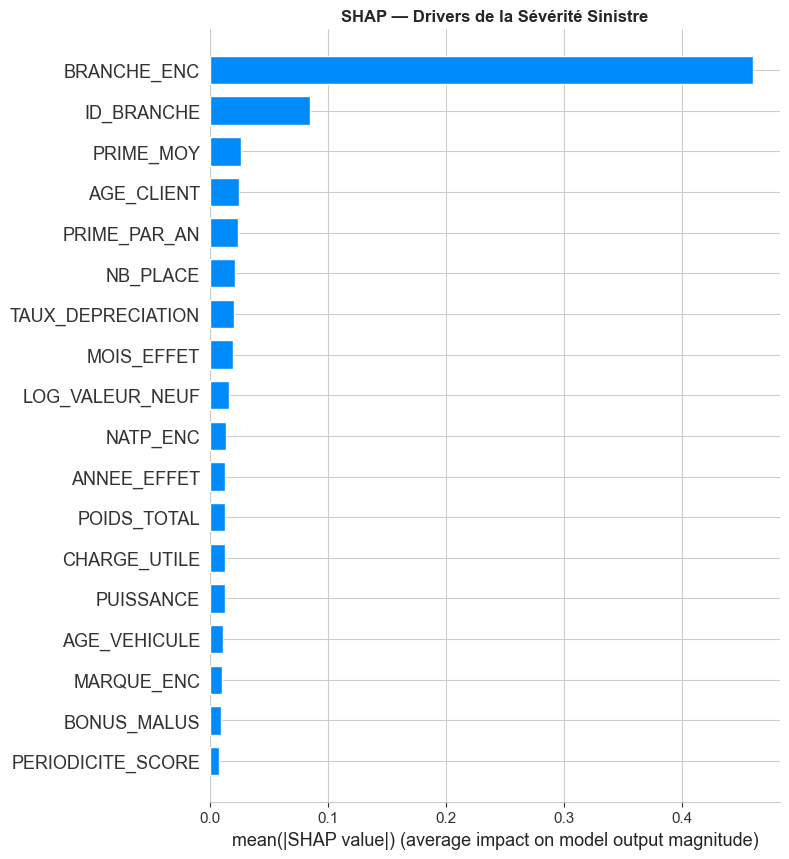

In [111]:
# SHAP beeswarm — direction d'impact
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_freq, X_freq_te, feature_names=FEATURE_COLS,
                  show=False, max_display=18)
plt.title('SHAP Beeswarm — Impact sur la Fréquence Sinistre', fontweight='bold')
plt.tight_layout(); plt.show()

# SHAP sévérité
explainer_sev = shap.TreeExplainer(lgb_sev)
shap_sev = explainer_sev.shap_values(X_sev_te)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_sev, X_sev_te, feature_names=FEATURE_COLS,
                  plot_type='bar', show=False, max_display=18)
plt.title('SHAP — Drivers de la Sévérité Sinistre', fontweight='bold')
plt.tight_layout(); plt.show()

## 10. Simulateur de Pricing — Nouvelle Police

In [112]:
def price_policy(police_features: dict, prime_actuelle: float = None) -> dict:
    """
    Calcule le profil de risque et la prime technique pour une police.

    Paramètres :
    - police_features  : dict avec les caractéristiques de la police
    - prime_actuelle   : prime annuelle actuelle (optionnel)

    Retourne :
    - dict complet avec risk score, prime technique, recommandations
    """
    row = pd.Series(X_all.median(), index=FEATURE_COLS)
    for k, v in police_features.items():
        if k in row.index:
            row[k] = v

    X_new = pd.DataFrame([row.values], columns=FEATURE_COLS)

    freq_pred  = float(lgb_freq.predict(X_new)[0])
    sev_pred   = float(np.expm1(lgb_sev.predict(X_new)[0]))
    prime_pure = freq_pred * sev_pred
    prime_tech = prime_pure * CHARGEMENT_TOTAL

    # Risk score — utilise normalize_scalar avec les ancres du portefeuille
    score_f = normalize_scalar(freq_pred, 'FREQ')
    score_s = normalize_scalar(sev_pred,  'SEV')
    risk_score = int(np.clip(W_FREQ * score_f + W_SEV * score_s, 0, 1000))
    risk_class, _ = classify_risk(risk_score)

    result = {
        '── RISQUE ──────────────────────────': '',
        'Risk Score [0-1000]'  : risk_score,
        'Classe de risque'     : risk_class,
        'Fréq. prédite (sin/an)': f'{freq_pred:.3f}',
        'Sévérité prédite (TND)': f'{sev_pred:,.0f}',
        '── TARIFICATION ────────────────────': '',
        'Prime pure (TND/an)'  : f'{prime_pure:,.0f}',
        'Prime technique (TND/an)': f'{prime_tech:,.0f}',
    }

    if prime_actuelle:
        ecart = prime_actuelle - prime_tech
        ecart_pct = ecart / prime_tech * 100
        result['Prime actuelle (TND/an)'] = f'{prime_actuelle:,.0f}'
        result['Écart (TND)']  = f'{ecart:+,.0f}'
        result['Écart (%)']    = f'{ecart_pct:+.1f}%'
        result['Statut']       = '✅ Sur-tarifé' if ecart > 0 else '⚠️ SOUS-TARIFÉ — Révision conseillée'

    return result


# ── Exemples ─────────────────────────────────────────────────────────────
print('═'*62)
print('POLICE 1 — VP, Audi, puissance 14, BM=8, client 35 ans')
print('═'*62)
r1 = price_policy({
    'BONUS_MALUS'      : 8,
    'PUISSANCE'        : 14,
    'CAT_PUISSANCE'    : 4,
    'AGE_VEHICULE'     : 3,
    'AGE_CLIENT'       : 35,
    'FLAG_MORALE'      : 0,
    'PERIODICITE_SCORE': 1,
    'TAUX_IMPAYE'      : 0,
    'ID_BRANCHE'       : 1,
}, prime_actuelle=600)
for k, v in r1.items():
    if k.startswith('──'): print(k)
    else: print(f'  {k:35s}: {v}')

print()
print('═'*62)
print('POLICE 2 — PL flotte, poids lourd, BM=9, multi-sinistres')
print('═'*62)
r2 = price_policy({
    'BONUS_MALUS'      : 9,
    'PUISSANCE'        : 22,
    'CAT_PUISSANCE'    : 5,
    'AGE_VEHICULE'     : 8,
    'FLAG_FLOTTE'      : 1,
    'TAUX_IMPAYE'      : 0.1,
    'NB_ANNULATIONS'   : 2,
    'ID_BRANCHE'       : 1,
    'POIDS_TOTAL'      : 35000,
}, prime_actuelle=1200)
for k, v in r2.items():
    if k.startswith('──'): print(k)
    else: print(f'  {k:35s}: {v}')

══════════════════════════════════════════════════════════════
POLICE 1 — VP, Audi, puissance 14, BM=8, client 35 ans
══════════════════════════════════════════════════════════════
── RISQUE ──────────────────────────
  Risk Score [0-1000]                : 156
  Classe de risque                   : B — Bon
  Fréq. prédite (sin/an)             : 0.245
  Sévérité prédite (TND)             : 1,176
── TARIFICATION ────────────────────
  Prime pure (TND/an)                : 288
  Prime technique (TND/an)           : 368
  Prime actuelle (TND/an)            : 600
  Écart (TND)                        : +232
  Écart (%)                          : +62.9%
  Statut                             : ✅ Sur-tarifé

══════════════════════════════════════════════════════════════
POLICE 2 — PL flotte, poids lourd, BM=9, multi-sinistres
══════════════════════════════════════════════════════════════
── RISQUE ──────────────────────────
  Risk Score [0-1000]                : 137
  Classe de risque            

## 11. Analyse du Portefeuille — Polices à Réviser en Priorité

In [113]:
# Top polices sous-tarifées à risque élevé
priority = df_freq[
    (df_freq['PRIME_TECHNIQUE'] > 0) &
    (df_freq['PRIME_PAR_AN'] > 0) &
    (df_freq['ECART_PRIME'] < -100)  # sous-tarifées de + 100 TND/an
].copy()

priority['PRIORITE_REVISION'] = (
    -priority['ECART_PRIME'] * priority['RISK_SCORE']
).rank(ascending=False).astype(int)

output_cols = [
    'ID_POLICE', 'BRANCHE', 'TYPE_POLICE',
    'BONUS_MALUS', 'NB_SINISTRES', 'SP_RATIO',
    'PRIME_PAR_AN', 'PRIME_TECHNIQUE', 'ECART_PRIME', 'ECART_PRIME_PCT',
    'PRED_FREQ', 'PRED_SEV', 'RISK_SCORE', 'RISK_CLASS',
    'PRIORITE_REVISION'
]
output_cols = [c for c in output_cols if c in priority.columns]

top_revision = priority.nsmallest(30, 'ECART_PRIME')[output_cols]

print(f'Polices à réviser en priorité : {len(priority):,}')
print(f'Manque à gagner total          : {-priority["ECART_PRIME"].sum():,.0f} TND/an')
print()

display(top_revision.style
    .background_gradient(subset=['ECART_PRIME_PCT'], cmap='Reds_r')
    .background_gradient(subset=['RISK_SCORE'], cmap='YlOrRd')
    .format({
        'BONUS_MALUS': '{:.0f}', 'SP_RATIO': '{:.2f}',
        'PRIME_PAR_AN': '{:,.0f}', 'PRIME_TECHNIQUE': '{:,.0f}',
        'ECART_PRIME': '{:+,.0f}', 'ECART_PRIME_PCT': '{:+.1f}%',
        'PRED_FREQ': '{:.3f}', 'PRED_SEV': '{:,.0f}'
    })
)

Polices à réviser en priorité : 5,063
Manque à gagner total          : 2,561,144 TND/an



,ID_POLICE,BRANCHE,TYPE_POLICE,BONUS_MALUS,NB_SINISTRES,SP_RATIO,PRIME_PAR_AN,PRIME_TECHNIQUE,ECART_PRIME,ECART_PRIME_PCT,PRED_FREQ,PRED_SEV,RISK_SCORE,RISK_CLASS,PRIORITE_REVISION
27670,27671,IRDS,individuel,nan,1.000000,0.00,232,"2,946","-2,714",-92.1%,0.271,"8,505",568,E — Critique,1
25339,25340,IRDS,flotte,nan,0.000000,0.00,320,"2,479","-2,159",-87.1%,0.223,"8,689",437,E — Critique,3
12278,12279,AUTO,individuel,4,4.000000,13.93,195,"2,259","-2,064",-91.4%,1.382,"1,277",560,E — Critique,2
24861,24862,IRDS,individuel,nan,1.000000,20.00,527,"2,468","-1,941",-78.6%,0.267,"7,211",476,E — Critique,4
24936,24937,IRDS,individuel,nan,1.000000,20.00,359,"2,195","-1,836",-83.6%,0.279,"6,156",485,E — Critique,5
20878,20879,IRDS,individuel,nan,1.000000,20.00,240,"2,047","-1,807",-88.3%,0.235,"6,803",448,E — Critique,7
11177,11178,AUTO,individuel,6,3.000000,6.14,432,"2,003","-1,571",-78.4%,1.295,"1,208",554,E — Critique,6
25380,25381,IRDS,individuel,nan,0.000000,0.00,163,"1,704","-1,541",-90.5%,0.211,"6,302",427,E — Critique,15
27991,27992,IRDS,individuel,nan,1.000000,0.00,178,"1,719","-1,541",-89.6%,0.208,"6,451",424,E — Critique,16
26093,26094,IRDS,individuel,nan,1.000000,20.00,479,"2,004","-1,525",-76.1%,0.270,"5,788",478,E — Critique,12


## 12. Export

In [114]:
import pickle

artifacts = {
    'lgb_freq':        lgb_freq,
    'lgb_sev':         lgb_sev,
    'xgb_freq':        xgb_freq,
    'xgb_sev':         xgb_sev,
    'encoders':        encoders,
    'feature_cols':    FEATURE_COLS,
    'chargement_total': CHARGEMENT_TOTAL,
    'price_fn':        price_policy,
}
with open('risk_scoring_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
print('✅ Modèles sauvegardés : risk_scoring_model.pkl')



✅ Modèles sauvegardés : risk_scoring_model.pkl


---
## 13. 📋 Synthèse — Utilisation en Production

### Architecture décisionnelle complète

```
                     SOUSCRIPTION / RENOUVELLEMENT
                              │
               ┌──────────────┴──────────────┐
               ▼                             ▼
        Risk Scoring                  Impayé Scoring
        ────────────                  ──────────────
        Fréquence prédite             Proba non-paiement
        Sévérité prédite              Score [0-1000]
        Prime technique
               │                             │
               ▼                             ▼
        Classe A–E                    Segment Très faible
                                              → Critique
               │                             │
               └──────────┬──────────────────┘
                          ▼
                   DÉCISION COMBINÉE
        ┌──────────────────────────────────────┐
        │ Risk=A, Impayé=Faible  → Prime -5%   │
        │ Risk=C, Impayé=Moyen   → Prime standard│
        │ Risk=E, Impayé=Élevé   → Prime +30%  │
        │                          ou refus     │
        └──────────────────────────────────────┘
```

### Grille tarifaire suggérée (ajustement multiplicateur)

| Classe Risque | Facteur Fréquence | Facteur Sévérité | Multiplicateur Final |
|---|---|---|---|
| A — Excellent | 0.70 | 0.85 | **×0.60** |
| B — Bon | 0.85 | 0.92 | **×0.78** |
| C — Moyen | 1.00 | 1.00 | **×1.00** |
| D — Élevé | 1.20 | 1.15 | **×1.38** |
| E — Critique | 1.50 | 1.35 | **×2.03** |
